# 05 – XAI Analysis: SHAP-Erklärung der Gebotsentscheidung

Dieses Notebook erklärt **warum** das Modell ein bestimmtes Gebot abgibt —
nicht wie gut es prognostiziert.

## Fragestellung

Im Newsvendor-Rahmen ist das optimale Gebot das τ\*-Quantil der Prognosedistribution:

$$b_t = Q_{\tau^*}(\hat{F}_t), \quad \tau^* = \frac{c_{under}}{c_{under} + c_{over}} = 0{,}524$$

SHAP (Lundberg & Lee 2017) zerlegt dieses Gebot additiv über alle Features:

$$b_t = \phi_0 + \sum_{i=1}^{p} \phi_i(x_t)$$

## Methodik

| Modell | Explainer | Begründung |
|--------|-----------|------------|
| Elastic Net | Koeffizienten (exakt) | Lineares Modell, direkt interpretierbar |
| QGB Q0.5 | TreeExplainer (exakt) | GradientBoostingRegressor, Theorem 1 in Lundberg & Lee |
| QRF | TreeExplainer (exakt) | Erklärt E[y\|x] als Proxy für das Quantil |
| Random Forest | TreeExplainer (exakt) | Point-Forecast-Vergleich |
| Neural Net | KernelExplainer (approx.) | Modellunabhängig, Abschn. 3.3 in Lundberg & Lee |

## Zentrale Forschungsfrage

Sind die Feature-Wichtigkeiten für die Gebotsentscheidung über verschiedene Modellklassen hinweg konsistent?
Falls ja, ist die Erklärbarkeit **modell-robust** — ein interpretierbares Modell verzichtet auf keine Information.

> **Methodische Einschraenkung - KernelExplainer (NN):**
> KernelExplainer approximiert SHAP-Werte durch Sampling von Feature-Koalitionen.
> Bei 21 Features und nsamples=300 werden nur ~300 von 2^21 moeglichen Koalitionen
> evaluiert. Die NN-SHAP-Werte sind daher instabil und nur als grobe Orientierung
> zu interpretieren, nicht als exakte Attribution.

## 0. Umgebungsprüfung

Python 3.12 mit sklearn ≥ 1.7 erforderlich (Modelle wurden damit gespeichert).

In [1]:
import sys
import sklearn, shap
print(f"Python:  {sys.version.split()[0]}")
print(f"sklearn: {sklearn.__version__}")
print(f"shap:    {shap.__version__}")
assert sys.version_info >= (3, 12), "Falscher Kernel! Bitte Python 3.12 auswählen."
assert tuple(int(x) for x in sklearn.__version__.split(".")[:2]) >= (1, 7), \
    f"sklearn zu alt: {sklearn.__version__} (brauche >= 1.7)"

Python:  3.12.1
sklearn: 1.7.1
shap:    0.51.0


## 1. Setup und Imports

In [2]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.xai.shap_analysis import shap_qgb, shap_qrf, shap_neural_net, shap_random_forest

MODELS_DIR   = PROJECT_ROOT / "results" / "models"
FORECAST_DIR = PROJECT_ROOT / "results" / "forecasts"
TABLES_DIR   = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR  = PROJECT_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# τ* aus Notebook 04
TAU_STAR = 0.5238
# Nächstes verfügbares Quantil im QGB-Modell (0.1, 0.25, 0.5, 0.75, 0.9)
TAU_QGB  = 0.5

print(f"Project root: {PROJECT_ROOT}")
print(f"τ* = {TAU_STAR:.4f}  →  QGB-Quantil: Q{TAU_QGB}")

Project root: C:\Users\felix\Documents\AI1\wind_bidding_project
τ* = 0.5238  →  QGB-Quantil: Q0.5


In [3]:
def plot_shap_bar(shap_values, feature_names, model_name, color, filename):
    """Gerichteter SHAP-Bar-Plot: mittlerer SHAP (signed) + P10–P90 als Fehlerbalken."""
    arr = np.array(shap_values)
    mean_s = pd.Series(np.abs(arr).mean(axis=0), index=feature_names)
    p10_s  = pd.Series(np.percentile(arr, 10, axis=0), index=feature_names)
    p90_s  = pd.Series(np.percentile(arr, 90, axis=0), index=feature_names)
    order  = mean_s.abs().sort_values().index
    mean_s, p10_s, p90_s = mean_s[order], p10_s[order], p90_s[order]
    bar_colors = [color for _ in mean_s]
    y_pos = np.arange(len(mean_s))
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(y_pos, mean_s.values, color=bar_colors, alpha=0.85)
    xerr_lo = np.clip(mean_s.values - p10_s.values, 0, None)
    xerr_hi = np.clip(p90_s.values - mean_s.values, 0, None)
    ax.errorbar(mean_s.values, y_pos, xerr=[xerr_lo, xerr_hi],
                fmt='none', color='#333333', capsize=3, linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(mean_s.index.tolist())
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel("Mittlerer SHAP-Wert [MWh]  (Fehlerbalken: P10–P90)")
    ax.set_title(f"{model_name} – Feature-Wichtigkeit (Richtung + Streuung)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

## 2. Daten laden und Train/Test rekonstruieren

Wir replizieren den exakten Feature-Engineering-Schritt aus Notebook 03,
um den echten `X_train` für den KernelExplainer-Background zu erhalten.
Alle Lag- und Rolling-Features werden identisch berechnet.

In [4]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

df_model = df.copy()
df_model["energy_mwh"] = df_model["power"].clip(lower=0) / 1000
df_model["hour"]       = df_model["timestamp"].dt.hour
df_model["dayofweek"]  = df_model["timestamp"].dt.dayofweek
df_model["month"]      = df_model["timestamp"].dt.month

df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)
df_model["dow_sin"]  = np.sin(2 * np.pi * df_model["dayofweek"] / 7)
df_model["dow_cos"]  = np.cos(2 * np.pi * df_model["dayofweek"] / 7)

# Gate-close: Gebote für Tag D+1 abgegeben um 12:00 Tag D.
# gate_close = Mitternacht des Zieldatums − 12h.
df_model["gate_close"] = (
    df_model["timestamp"].dt.normalize() - pd.Timedelta(hours=12)
)

full_hourly_idx = pd.date_range(
    df["timestamp"].min().normalize() - pd.Timedelta(days=8),
    df["timestamp"].max(),
    freq="h",
)

energy_hourly = (
    df_model.set_index("timestamp")["energy_mwh"]
    .groupby(level=0).mean()
    .reindex(full_hourly_idx)
)
energy_roll24  = energy_hourly.rolling(24,  min_periods=12).mean()
energy_std24   = energy_hourly.rolling(24,  min_periods=12).std()
energy_roll168 = energy_hourly.rolling(168, min_periods=72).mean()
energy_std168  = energy_hourly.rolling(168, min_periods=72).std()

for offset_h in [0, 12, 24, 48, 168]:
    col = "energy_at_gate" if offset_h == 0 else f"energy_gate_m{offset_h}h"
    df_model[col] = (
        df_model["gate_close"] - pd.Timedelta(hours=offset_h)
    ).map(energy_hourly).values

df_model["energy_roll24_at_gate"]      = df_model["gate_close"].map(energy_roll24).values
df_model["energy_roll_std24_at_gate"]  = df_model["gate_close"].map(energy_std24).values
df_model["energy_roll168_at_gate"]     = df_model["gate_close"].map(energy_roll168).values
df_model["energy_roll_std168_at_gate"] = df_model["gate_close"].map(energy_std168).values

if "wind_speed" in df_model.columns:
    wind_hourly = (
        df_model.set_index("timestamp")["wind_speed"]
        .groupby(level=0).mean()
        .reindex(full_hourly_idx)
    )
    wind_roll24  = wind_hourly.rolling(24,  min_periods=12).mean()
    wind_std24   = wind_hourly.rolling(24,  min_periods=12).std()
    wind_roll168 = wind_hourly.rolling(168, min_periods=72).mean()
    wind_std168  = wind_hourly.rolling(168, min_periods=72).std()

    for offset_h in [0, 12, 24, 168]:
        col = "wind_at_gate" if offset_h == 0 else f"wind_gate_m{offset_h}h"
        df_model[col] = (
            df_model["gate_close"] - pd.Timedelta(hours=offset_h)
        ).map(wind_hourly).values

    df_model["wind_roll24_at_gate"]      = df_model["gate_close"].map(wind_roll24).values
    df_model["wind_roll_std24_at_gate"]  = df_model["gate_close"].map(wind_std24).values
    df_model["wind_roll168_at_gate"]     = df_model["gate_close"].map(wind_roll168).values
    df_model["wind_roll_std168_at_gate"] = df_model["gate_close"].map(wind_std168).values

BASE_FEATURES = [
    "energy_at_gate", "energy_gate_m12h", "energy_gate_m24h",
    "energy_gate_m48h", "energy_gate_m168h",
    "energy_roll24_at_gate", "energy_roll_std24_at_gate",
    "energy_roll168_at_gate", "energy_roll_std168_at_gate",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month",
]
WIND_FEATURES = [f for f in [
    "wind_at_gate", "wind_gate_m12h", "wind_gate_m24h", "wind_gate_m168h",
    "wind_roll24_at_gate", "wind_roll_std24_at_gate",
    "wind_roll168_at_gate", "wind_roll_std168_at_gate",
] if f in df_model.columns]
FEATURES = BASE_FEATURES + WIND_FEATURES
TARGET   = "energy_mwh"

df_model = df_model.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
X = df_model[FEATURES].to_numpy()

split_idx = int(len(df_model) * 0.8)
X_train = X[:split_idx]
X_test  = X[split_idx:]

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"X_train:  {X_train.shape}")
print(f"X_test:   {X_test.shape}")

Features (22): ['energy_at_gate', 'energy_gate_m12h', 'energy_gate_m24h', 'energy_gate_m48h', 'energy_gate_m168h', 'energy_roll24_at_gate', 'energy_roll_std24_at_gate', 'energy_roll168_at_gate', 'energy_roll_std168_at_gate', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month', 'wind_at_gate', 'wind_gate_m12h', 'wind_gate_m24h', 'wind_gate_m168h', 'wind_roll24_at_gate', 'wind_roll_std24_at_gate', 'wind_roll168_at_gate', 'wind_roll_std168_at_gate']
X_train:  (55260, 22)
X_test:   (13816, 22)


## 3. Modelle laden

In [5]:
warnings.filterwarnings("ignore", category=UserWarning)

qgb_models = joblib.load(MODELS_DIR / "quantile_gradient_boosting_day_ahead.joblib")
qrf_model  = joblib.load(MODELS_DIR / "qrf_day_ahead.joblib")
rf_model   = joblib.load(MODELS_DIR / "random_forest_day_ahead.joblib")
en_model   = joblib.load(MODELS_DIR / "elastic_net_day_ahead.joblib")
nn_model   = joblib.load(MODELS_DIR / "neural_network_day_ahead.joblib")

# Kompatibilitätsprüfung Neural Net
try:
    n_nn_features = nn_model.named_steps["scaler"].n_features_in_
except Exception:
    n_nn_features = -1

if n_nn_features != len(FEATURES):
    print(f"nn_model hat {n_nn_features} Features statt {len(FEATURES)} -> trainiere neu ...")
    from src.models import neural_net as neural_net_module
    y = df_model[TARGET].to_numpy()
    nn_model = neural_net_module.train(
        X_train, y[:split_idx],
        hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42,
    )
    joblib.dump(nn_model, MODELS_DIR / "neural_network_day_ahead.joblib")
    print("  Gespeichert: neural_network_day_ahead.joblib (21 Features)")
    n_nn_features = len(FEATURES)

print(f"QGB Quantile:  {sorted(qgb_models.keys())}")
print(f"QRF:           {type(qrf_model).__name__}")
print(f"RF:            {type(rf_model).__name__}  ({rf_model.n_estimators} Bäume)")
print(f"Elastic Net:   {type(en_model).__name__}")
print(f"Neural Net:    {type(nn_model).__name__}  ({n_nn_features} Features)")

QGB Quantile:  [0.1, 0.25, 0.5, 0.75, 0.9]
QRF:           RandomForestRegressor
RF:            RandomForestRegressor  (300 Bäume)
Elastic Net:   Pipeline
Neural Net:    Pipeline  (22 Features)


## 4. Elastic Net – Koeffizienten (interpretierbare Baseline)

Elastic Net ist ein lineares Modell: jeder Koeffizient gibt direkt an,
um wie viele MWh das Gebot steigt, wenn das Feature um eine Einheit zunimmt
(ceteris paribus). Features mit Koeffizient ≈ 0 wurden durch L1-Regularisierung eliminiert.

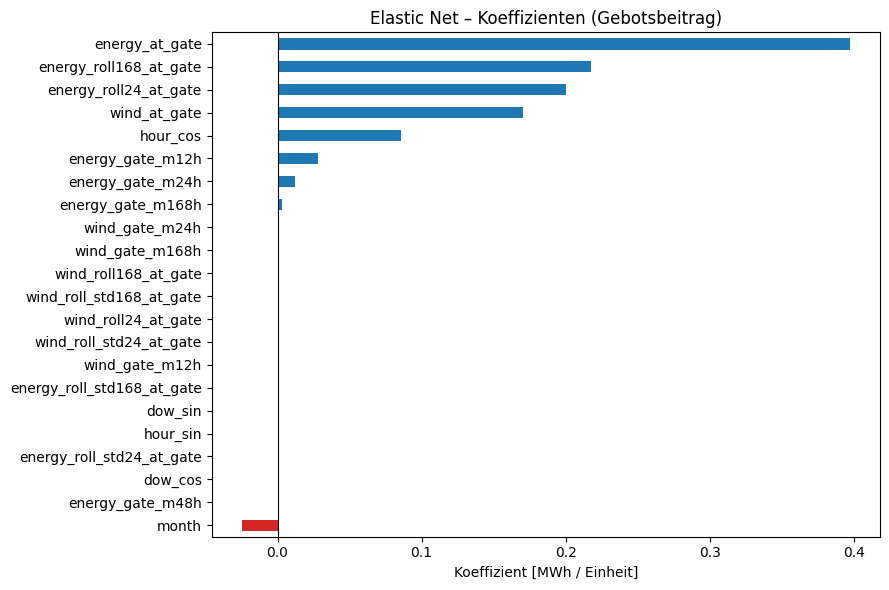

Top-Features (Elastic Net):


,Koeffizient [MWh/Einheit]
energy_at_gate,0.397254
energy_roll168_at_gate,0.217373
energy_roll24_at_gate,0.200600
wind_at_gate,0.170756
hour_cos,0.085691
energy_gate_m12h,0.028008
energy_gate_m24h,0.012130
energy_gate_m168h,0.003213
energy_gate_m48h,0.000000
energy_roll_std168_at_gate,0.000000


In [6]:
coefs = pd.Series(
    en_model.named_steps["elastic_net"].coef_,
    index=FEATURES,
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#d62728" if c < 0 else "#1f77b4" for c in coefs.sort_values()]
coefs.sort_values().plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Elastic Net – Koeffizienten (Gebotsbeitrag)")
ax.set_xlabel("Koeffizient [MWh / Einheit]")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_en_coefs.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top-Features (Elastic Net):")
display(coefs.sort_values(ascending=False).rename("Koeffizient [MWh/Einheit]").to_frame())

## 5. SHAP – Quantile Gradient Boosting (τ\*-Modell)

Das QGB-Modell mit `alpha=0.5` (nächstes verfügbares Quantil zu τ\*=0.524) wird direkt erklärt.
TreeExplainer liefert **exakte** SHAP-Werte in polynomialer Laufzeit (Theorem 1, Lundberg & Lee 2017).

Die SHAP-Werte messen die Abweichung des Gebots vom Erwartungswert $\mathbb{E}[Q_{0.5}]$,
aufgeteilt auf einzelne Features.

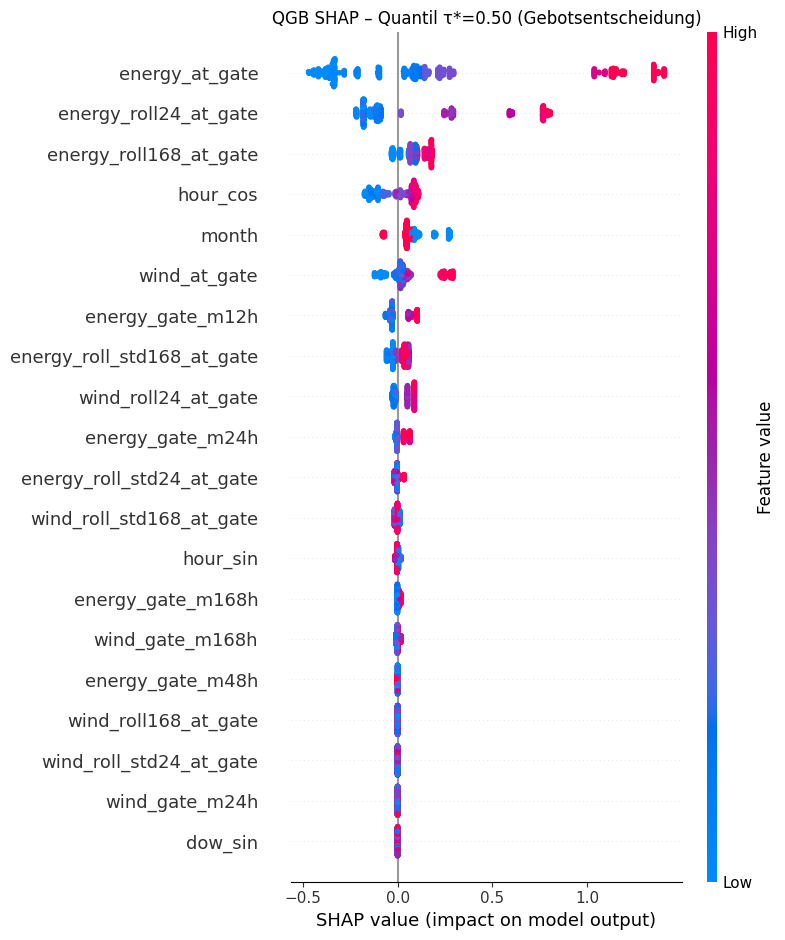

SHAP-Matrix Shape: (500, 22)

Mittlerer |SHAP| pro Feature:


,|SHAP| QGB
energy_at_gate,0.470665
energy_roll24_at_gate,0.300469
energy_roll168_at_gate,0.095303
hour_cos,0.091286
month,0.089316
wind_at_gate,0.080091
energy_gate_m12h,0.051354
energy_roll_std168_at_gate,0.040322
wind_roll24_at_gate,0.037735
energy_gate_m24h,0.017421


In [7]:
shap_vals_qgb = shap_qgb(
    qgb_models, tau_star=TAU_QGB, X_test=X_test[:500], feature_names=FEATURES,
)

print(f"SHAP-Matrix Shape: {shap_vals_qgb.shape}")
mean_abs_qgb = pd.Series(np.abs(shap_vals_qgb).mean(axis=0), index=FEATURES, name="|SHAP| QGB")
print("\nMittlerer |SHAP| pro Feature:")
display(mean_abs_qgb.sort_values(ascending=False).to_frame())

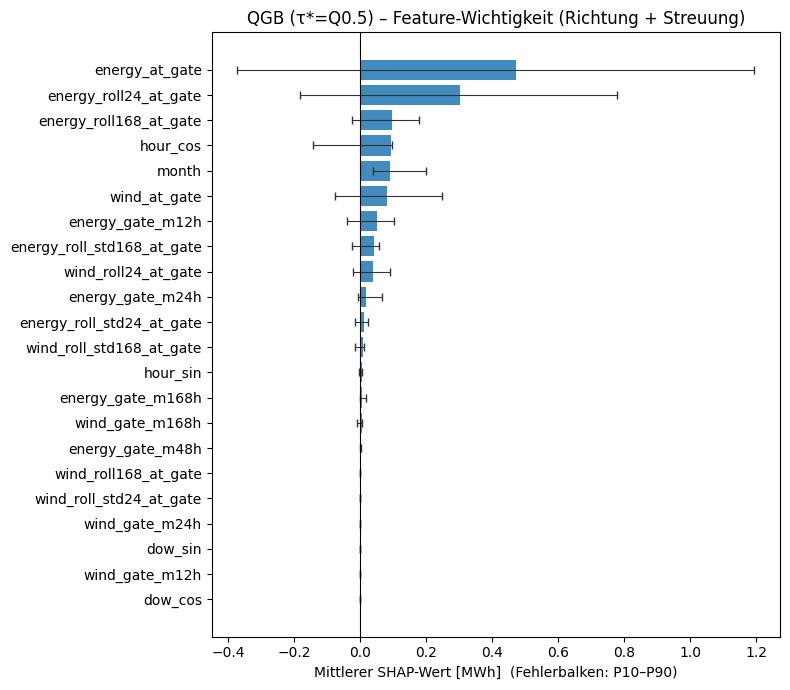

In [8]:
plot_shap_bar(shap_vals_qgb, FEATURES, "QGB (τ*=Q0.5)", "#1f77b4", "shap_qgb_bar.png")

## 6. SHAP – Quantile Regression Forest (E[y|X]-Proxy)

Der QRF nutzt intern einen `RandomForestRegressor` (MSE-Training).
TreeExplainer erklärt daher $\mathbb{E}[y|x]$ als Proxy für die Quantilattribution.
Die Feature-Rangfolge bleibt gültig, solange die Quantile monoton von $\mathbb{E}[y|x]$ abhängen.

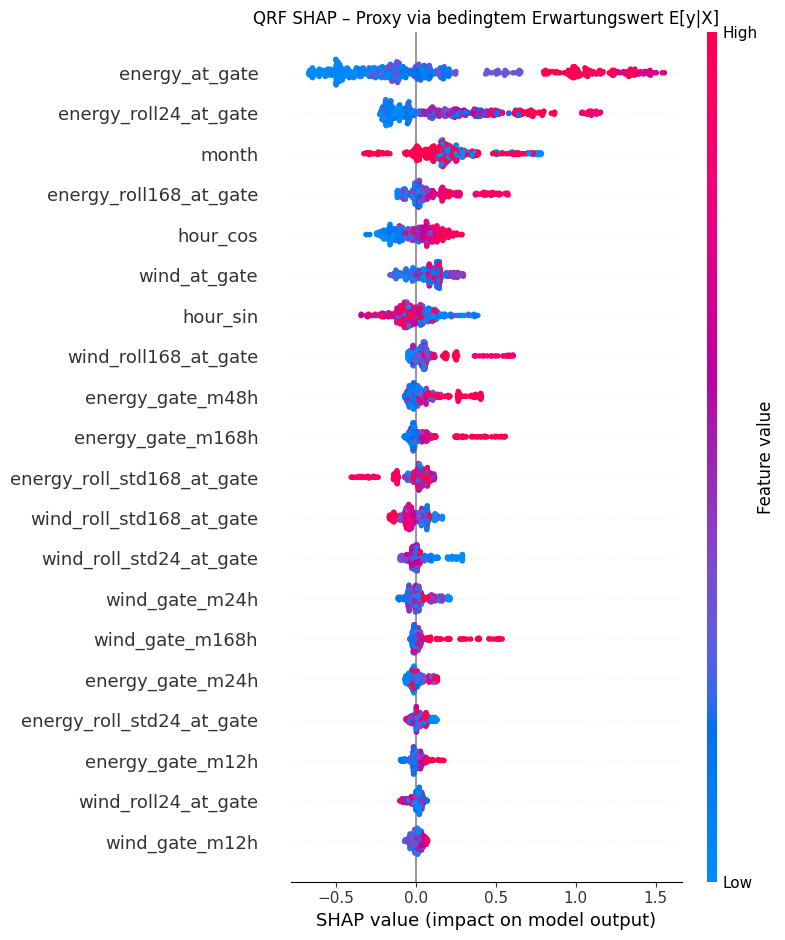

SHAP-Matrix Shape: (500, 22)

Mittlerer |SHAP| pro Feature:


,|SHAP| QRF
energy_at_gate,0.487666
energy_roll24_at_gate,0.294781
month,0.212305
energy_roll168_at_gate,0.113707
hour_cos,0.107863
wind_at_gate,0.102894
hour_sin,0.088137
wind_roll168_at_gate,0.080698
energy_gate_m48h,0.077392
energy_gate_m168h,0.067291


In [9]:
shap_vals_qrf = shap_qrf(
    qrf_model, X_test=X_test[:500], feature_names=FEATURES,
)

print(f"SHAP-Matrix Shape: {shap_vals_qrf.shape}")
mean_abs_qrf = pd.Series(np.abs(shap_vals_qrf).mean(axis=0), index=FEATURES, name="|SHAP| QRF")
print("\nMittlerer |SHAP| pro Feature:")
display(mean_abs_qrf.sort_values(ascending=False).to_frame())

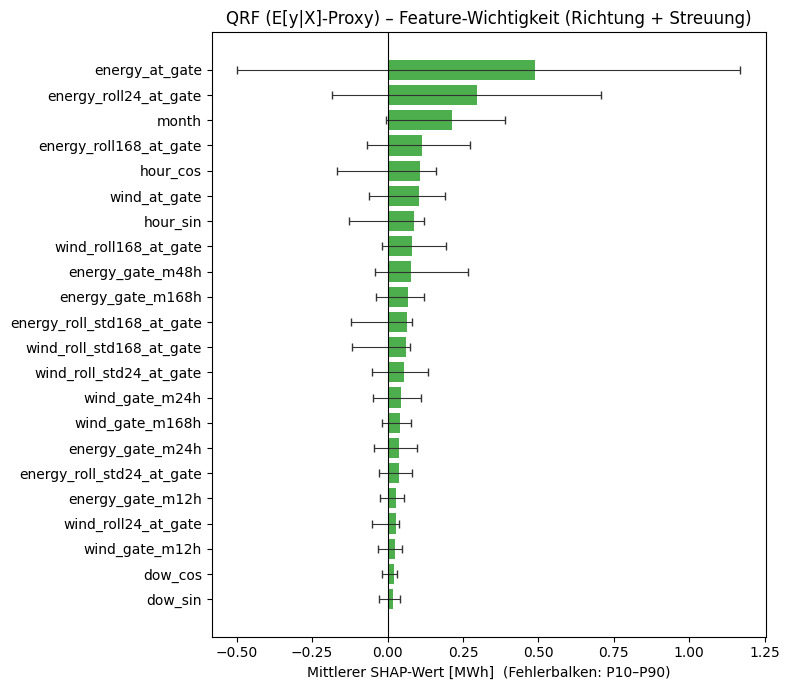

In [10]:
plot_shap_bar(shap_vals_qrf, FEATURES, "QRF (E[y|X]-Proxy)", "#2ca02c", "shap_qrf_bar.png")

## 7. SHAP – Neural Net (KernelExplainer)

KernelExplainer ist modellunabhängig (Abschn. 3.3, Lundberg & Lee 2017).
Er approximiert SHAP via gewichteter linearer Regression über Feature-Koalitionen.

- **Background:** 50 k-Means-Cluster aus X_train (repräsentiert $\mathbb{E}[f(X)]$)
- **nsamples=300:** stabile Schätzung (bei 21 Features: $2^{21}$ mögliche Koalitionen → Sampling)
- **Hinweis:** Läuft einige Minuten (100 Testpunkte × 300 Samples).

WARNUNG: NN-SHAP via KernelExplainer ist eine grobe Approximation (nsamples=300 von 2^21 Koalitionen). Mit Vorsicht interpretieren.


  0%|          | 0/100 [00:00<?, ?it/s]

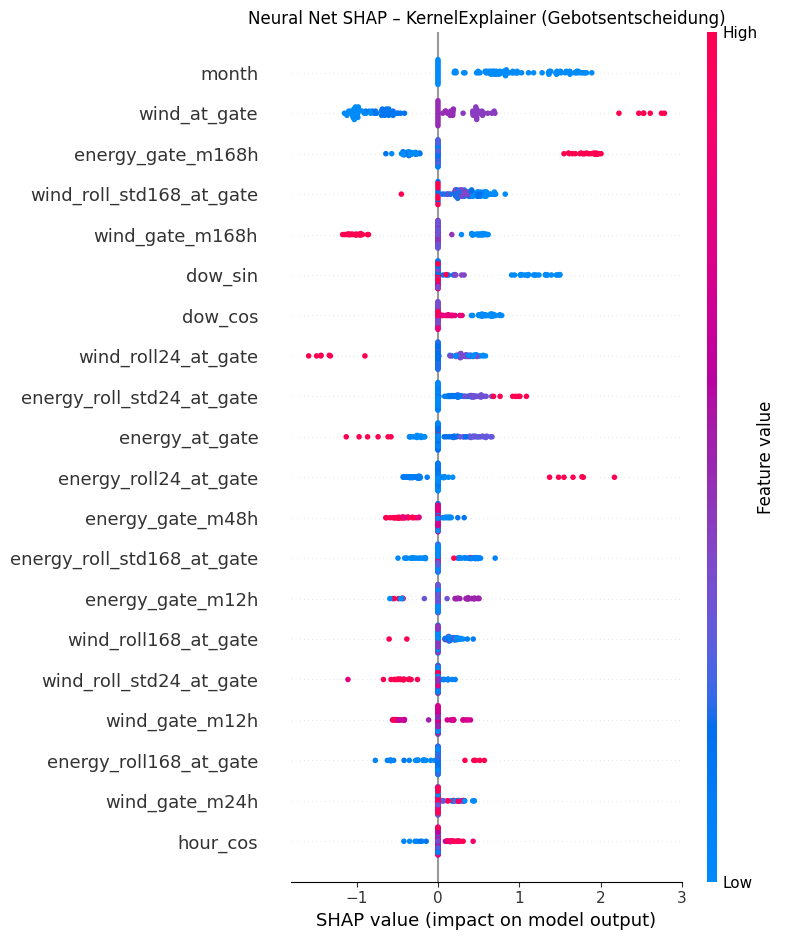

SHAP-Matrix Shape: (100, 22)

Mittlerer |SHAP| pro Feature:


,|SHAP| NN
month,0.823364
wind_at_gate,0.695251
energy_gate_m168h,0.508233
wind_roll_std168_at_gate,0.340267
wind_gate_m168h,0.337604
dow_sin,0.306782
dow_cos,0.295598
wind_roll24_at_gate,0.258059
energy_roll_std24_at_gate,0.239807
energy_at_gate,0.221816


In [11]:
import warnings
warnings.warn(
    "KernelExplainer (NN): Approximation, Ergebnisse nur orientierend.",
    UserWarning, stacklevel=2
)
print("WARNUNG: NN-SHAP via KernelExplainer ist eine grobe Approximation"
      " (nsamples=300 von 2^21 Koalitionen). Mit Vorsicht interpretieren.")

shap_vals_nn = shap_neural_net(
    nn_model, X_test=X_test[:100], X_train=X_train,
    feature_names=FEATURES, n_background=50, nsamples=300,
)

shap_arr_nn = np.array(shap_vals_nn)
print(f"SHAP-Matrix Shape: {shap_arr_nn.shape}")
mean_abs_nn = pd.Series(np.abs(shap_arr_nn).mean(axis=0), index=FEATURES, name="|SHAP| NN")
print("\nMittlerer |SHAP| pro Feature:")
display(mean_abs_nn.sort_values(ascending=False).to_frame())

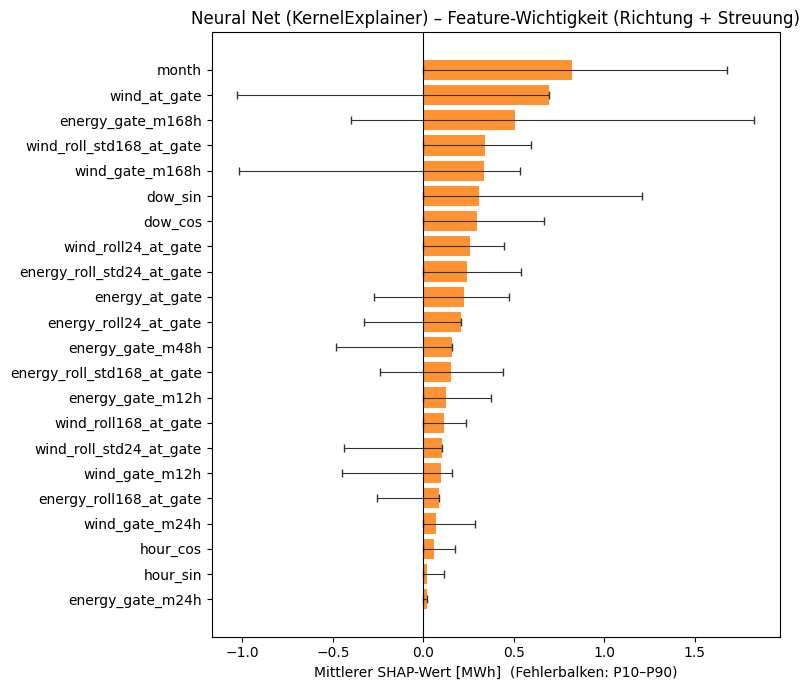

In [12]:
plot_shap_bar(shap_arr_nn, FEATURES, "Neural Net (KernelExplainer)", "#ff7f0e", "shap_nn_bar.png")

## 8. SHAP – Random Forest (Point Forecast, Vergleich)

Der Point-Forecast-RF bietet $\hat{y}$ direkt als Gebot (kein Quantil-Tuning).
Er dient zum modellübergreifenden Vergleich der Feature-Wichtigkeiten.

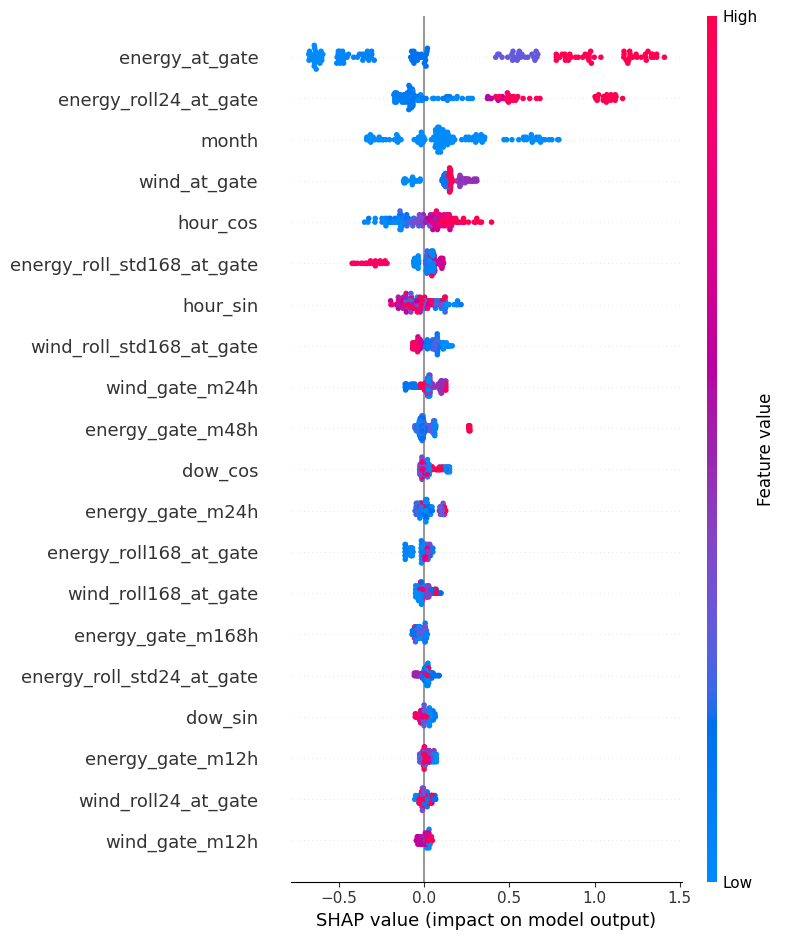

SHAP-Matrix Shape: (150, 22)

Mittlerer |SHAP| pro Feature:


,|SHAP| RF
energy_at_gate,0.632817
energy_roll24_at_gate,0.347125
month,0.232407
wind_at_gate,0.160152
hour_cos,0.128242
energy_roll_std168_at_gate,0.089114
hour_sin,0.081596
wind_roll_std168_at_gate,0.060636
wind_gate_m24h,0.059605
energy_gate_m48h,0.041082


In [13]:
shap_vals_rf = shap_random_forest(
    rf_model, X_test=X_test[:500], feature_names=FEATURES,
)

print(f"SHAP-Matrix Shape: {shap_vals_rf.shape}")
mean_abs_rf = pd.Series(np.abs(shap_vals_rf).mean(axis=0), index=FEATURES, name="|SHAP| RF")
print("\nMittlerer |SHAP| pro Feature:")
display(mean_abs_rf.sort_values(ascending=False).to_frame())

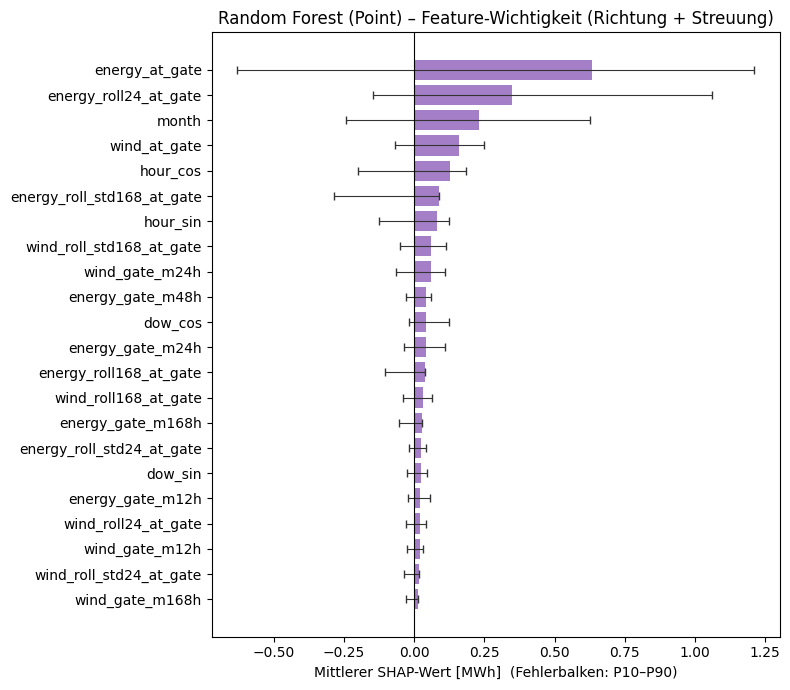

In [14]:
plot_shap_bar(shap_vals_rf, FEATURES, "Random Forest (Point)", "#9467bd", "shap_rf_bar.png")

## 9. Vergleich: Feature-Rangfolge – TreeExplainer-Modelle (QGB, QRF, RF)

Alle drei Modelle nutzen TreeExplainer (exakt). Da die SHAP-Skalen vergleichbar sind,
können die absoluten Wichtigkeiten direkt gegenübergestellt werden.
Das Neural Net (KernelExplainer, andere Skala) wird separat gezeigt.

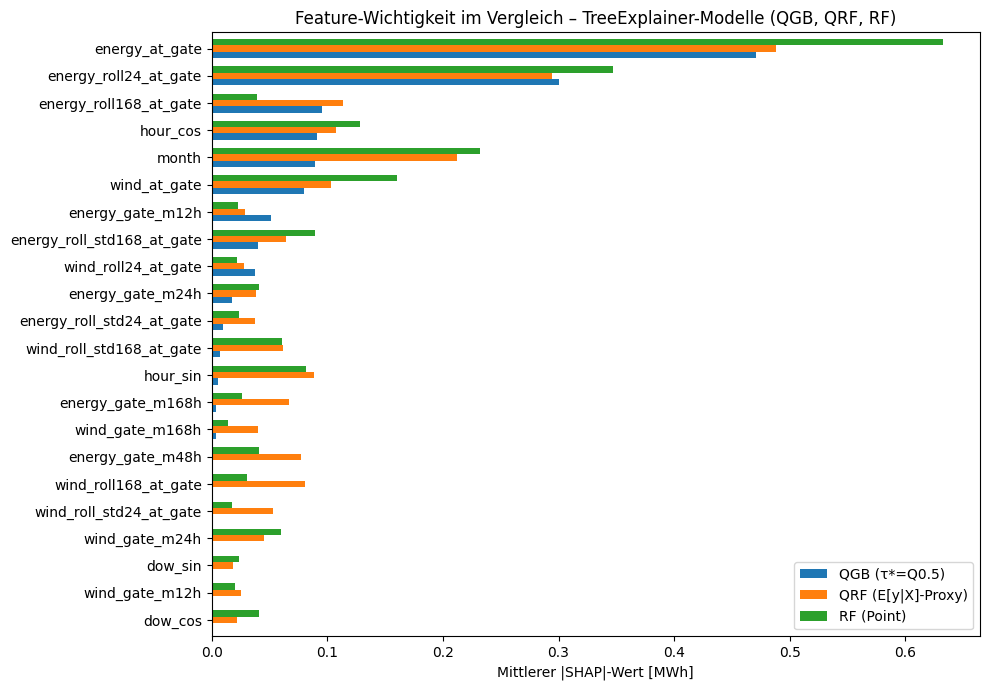


Spearman-Rangkorrelation der Feature-Wichtigkeiten (TreeExplainer):


,Modell A,Modell B,Spearman rho,p-Wert
0,QGB (τ*=Q0.5),QRF (E[y|X]-Proxy),0.645,0.0012
1,QGB (τ*=Q0.5),RF (Point),0.588,0.0040
2,QRF (E[y|X]-Proxy),RF (Point),0.736,0.0001


In [15]:
importance_df = pd.DataFrame({
    "QGB (τ*=Q0.5)":    pd.Series(np.abs(shap_vals_qgb).mean(axis=0), index=FEATURES),
    "QRF (E[y|X]-Proxy)": pd.Series(np.abs(shap_vals_qrf).mean(axis=0), index=FEATURES),
    "RF (Point)":          pd.Series(np.abs(shap_vals_rf).mean(axis=0),  index=FEATURES),
}).sort_values("QGB (τ*=Q0.5)", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importance_df.plot(kind="barh", ax=ax, width=0.7,
                   color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax.set_xlabel("Mittlerer |SHAP|-Wert [MWh]")
ax.set_title("Feature-Wichtigkeit im Vergleich – TreeExplainer-Modelle (QGB, QRF, RF)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_feature_importance_comparison_tree.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSpearman-Rangkorrelation der Feature-Wichtigkeiten (TreeExplainer):")
from scipy.stats import spearmanr
cols = importance_df.columns.tolist()
corr_rows = []
for i, c1 in enumerate(cols):
    for c2 in cols[i+1:]:
        rho, pval = spearmanr(importance_df[c1], importance_df[c2])
        corr_rows.append({"Modell A": c1, "Modell B": c2, "Spearman rho": round(rho, 3), "p-Wert": round(pval, 4)})
display(pd.DataFrame(corr_rows))

## 9b. SHAP nach Monat – Saisonale Feature-Wichtigkeit (QGB)

Zeigt ob die Wichtigkeit einzelner Features saisonal variiert.
Stabile Rankings über alle Monate → Erklärung ist zeitlich robust.

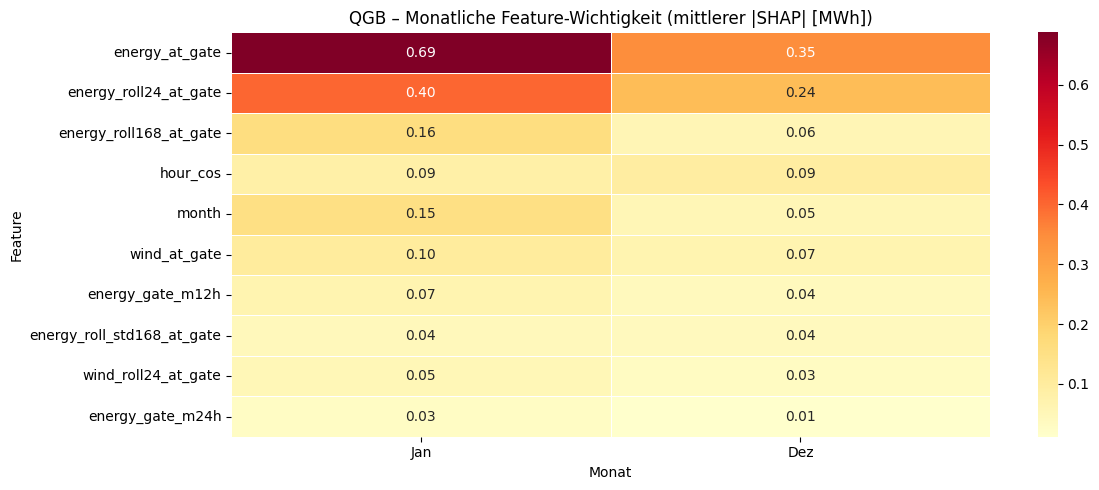

In [16]:
import seaborn as sns

test_ts = df_model["timestamp"].iloc[split_idx: split_idx + 500].reset_index(drop=True)
test_months = test_ts.dt.month

top_features = (pd.Series(np.abs(shap_vals_qgb).mean(axis=0), index=FEATURES)
                  .sort_values(ascending=False).head(10).index.tolist())

monthly_data = {}
for m in sorted(test_months.unique()):
    mask = (test_months == m).values
    if mask.sum() >= 5:
        monthly_data[m] = np.abs(shap_vals_qgb[mask]).mean(axis=0)

monthly_df = pd.DataFrame(monthly_data, index=FEATURES).T
month_labels = {1:"Jan",2:"Feb",3:"Mär",4:"Apr",5:"Mai",6:"Jun",
                7:"Jul",8:"Aug",9:"Sep",10:"Okt",11:"Nov",12:"Dez"}
monthly_df.index = [month_labels[m] for m in monthly_df.index]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(monthly_df[top_features].T, annot=True, fmt=".2f",
            cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("QGB – Monatliche Feature-Wichtigkeit (mittlerer |SHAP| [MWh])")
ax.set_xlabel("Monat")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_qgb_monthly.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Einzelbeispiel: SHAP Waterfall Plot (QGB)

Für einen einzelnen Zeitpunkt zeigt der Waterfall Plot, welche Features
das Gebot nach oben oder unten treiben.
Gewählt wird der Testpunkt mit dem größten SHAP-Gesamtbetrag
(d.h. die am stärksten vom Erwartungswert abweichende Gebotssituation).

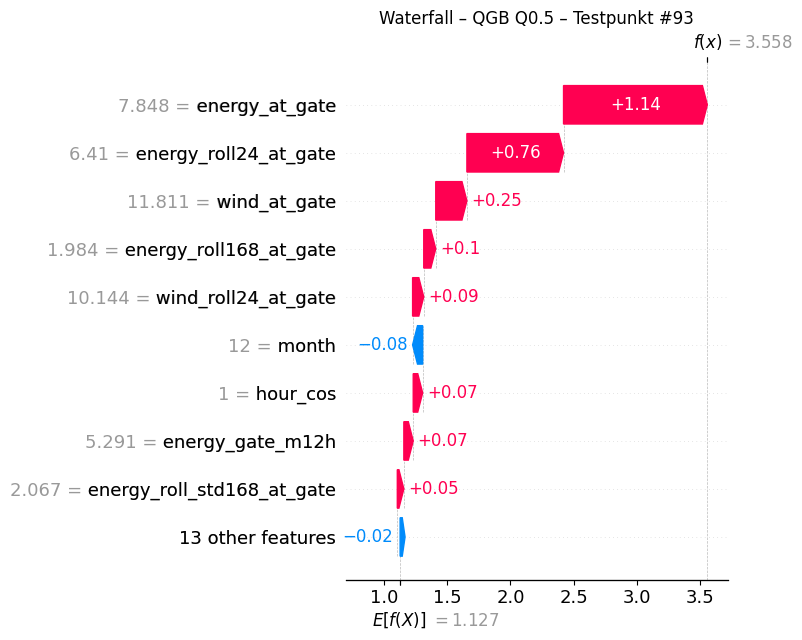

Gemeinsamer Testpunkt: #93
Erwartungswert E[f(X)] = 1.127 MWh
Gebot: 3.558 MWh
Feature-Werte:
  energy_at_gate            =   7.848   SHAP: +1.138
  energy_roll24_at_gate     =   6.410   SHAP: +0.764
  wind_at_gate              =  11.811   SHAP: +0.246
  energy_roll168_at_gate    =   1.984   SHAP: +0.095
  wind_roll24_at_gate       =  10.144   SHAP: +0.088
  month                     =  12.000   SHAP: -0.080
  hour_cos                  =   1.000   SHAP: +0.075
  energy_gate_m12h          =   5.291   SHAP: +0.074


In [17]:
import shap

# Gemeinsamer Testpunkt für alle Waterfall-Plots (erste 100 Punkte = kleinste gemeinsame Teilmenge wegen NN)
SHARED_IDX = int(np.argmax(np.abs(shap_vals_qgb[:100]).sum(axis=1)))

explainer_qgb = shap.TreeExplainer(qgb_models[TAU_QGB])
base_val_qgb  = float(np.atleast_1d(explainer_qgb.expected_value)[0])

exp = shap.Explanation(
    values=shap_vals_qgb[SHARED_IDX],
    base_values=base_val_qgb,
    data=X_test[:100][SHARED_IDX],
    feature_names=FEATURES,
)

shap.waterfall_plot(exp, show=False)
plt.title(f"Waterfall – QGB Q{TAU_QGB} – Testpunkt #{SHARED_IDX}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_qgb_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Gemeinsamer Testpunkt: #{SHARED_IDX}")
print(f"Erwartungswert E[f(X)] = {base_val_qgb:.3f} MWh")
print(f"Gebot: {shap_vals_qgb[SHARED_IDX].sum() + base_val_qgb:.3f} MWh")
print("Feature-Werte:")
for fname, fval, sval in sorted(
    zip(FEATURES, X_test[:100][SHARED_IDX], shap_vals_qgb[SHARED_IDX]),
    key=lambda x: abs(x[2]), reverse=True
)[:8]:
    print(f"  {fname:<25} = {fval:7.3f}   SHAP: {sval:+.3f}")

## 10b. Waterfall Plots – alle Modelle

Für jedes Modell wird derselbe Ansatz verwendet: der Testpunkt mit dem größten SHAP-Gesamtbetrag.

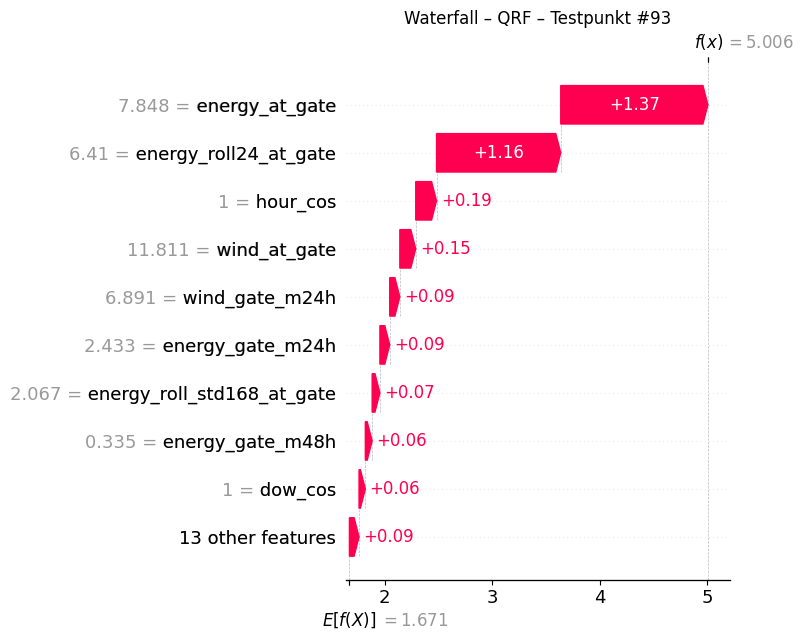

E[f(X)] = 1.671 MWh  |  Gebot = 5.006 MWh


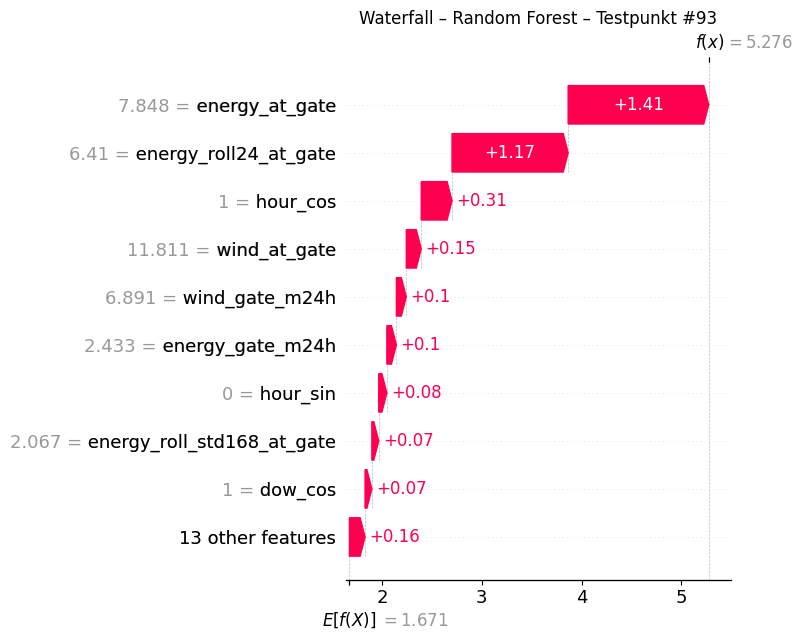

E[f(X)] = 1.671 MWh  |  Gebot = 5.276 MWh


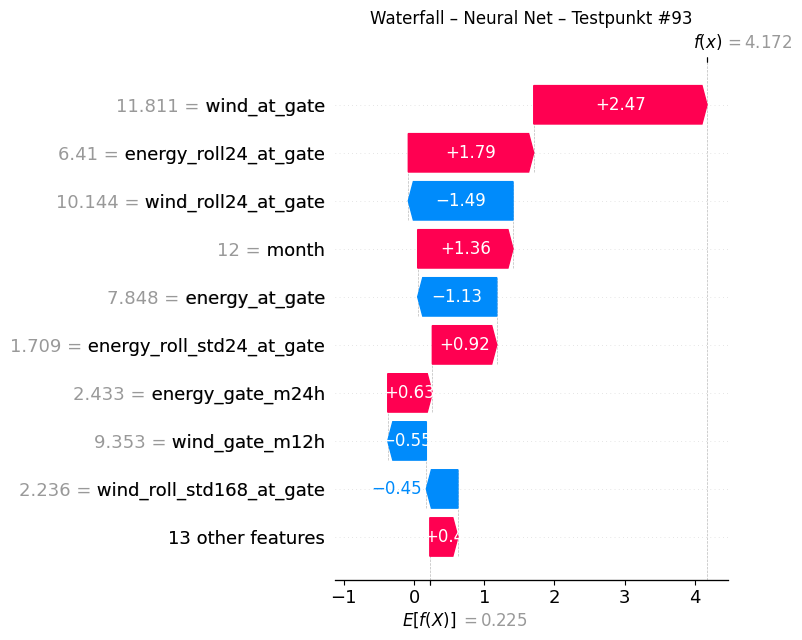

E[f(X)] ≈ 0.225 MWh  |  Gebot = 4.172 MWh


In [18]:
X_test_100 = X_test[:100]

def waterfall_for_model(shap_values, explainer, X_subset, feature_names, model_name, filename, idx):
    base_val = float(np.atleast_1d(explainer.expected_value)[0])
    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=base_val,
        data=X_subset[idx],
        feature_names=feature_names,
    )
    shap.waterfall_plot(exp, show=False)
    plt.title(f"Waterfall – {model_name} – Testpunkt #{idx}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"E[f(X)] = {base_val:.3f} MWh  |  Gebot = {shap_values[idx].sum() + base_val:.3f} MWh")

# QRF Waterfall
explainer_qrf = shap.TreeExplainer(qrf_model)
waterfall_for_model(shap_vals_qrf, explainer_qrf, X_test_100, FEATURES, "QRF", "shap_qrf_waterfall.png", SHARED_IDX)

# RF Waterfall
explainer_rf = shap.TreeExplainer(rf_model)
waterfall_for_model(shap_vals_rf, explainer_rf, X_test_100, FEATURES, "Random Forest", "shap_rf_waterfall.png", SHARED_IDX)

# NN Waterfall
nn_base_value = float(nn_model.predict(X_train[:200]).mean())
exp_nn = shap.Explanation(
    values=shap_arr_nn[SHARED_IDX],
    base_values=nn_base_value,
    data=X_test_100[SHARED_IDX],
    feature_names=FEATURES,
)
shap.waterfall_plot(exp_nn, show=False)
plt.title(f"Waterfall – Neural Net – Testpunkt #{SHARED_IDX}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_nn_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"E[f(X)] ≈ {nn_base_value:.3f} MWh  |  Gebot = {shap_arr_nn[SHARED_IDX].sum() + nn_base_value:.3f} MWh")

## 12. LIME – Vergleich und Begründung der Ungeeignetheit

LIME (Local Interpretable Model-agnostic Explanations, Ribeiro et al. 2016)
erklärt eine Vorhersage durch ein lokales lineares Surrogat-Modell.

**Vorgehen:** Perturbiere den Eingabepunkt → berechne Modelloutputs → fitte lokales lineares Modell.

**Warum LIME für diesen Anwendungsfall ungeeignet ist:**

| Kriterium | SHAP | LIME |
|-----------|------|------|
| Axiomatische Basis | ✓ Shapley-Axiome (Effizienz, Symmetrie, Dummy, Additivität) | ✗ keine Garantie |
| Konsistenz | ✓ (TreeExplainer exakt) | ✗ Kernel-Breite ε beliebig |
| Stabilität | ✓ deterministisch | ✗ sampling-abhängig |
| Skala | MWh (interpretierbar) | a.u. (willkürlich) |
| Lokalitätsannahme | nicht erforderlich | lokal linear (verletzt bei Bäumen) |

**Fazit**: SHAP wird für alle Modelle bevorzugt.

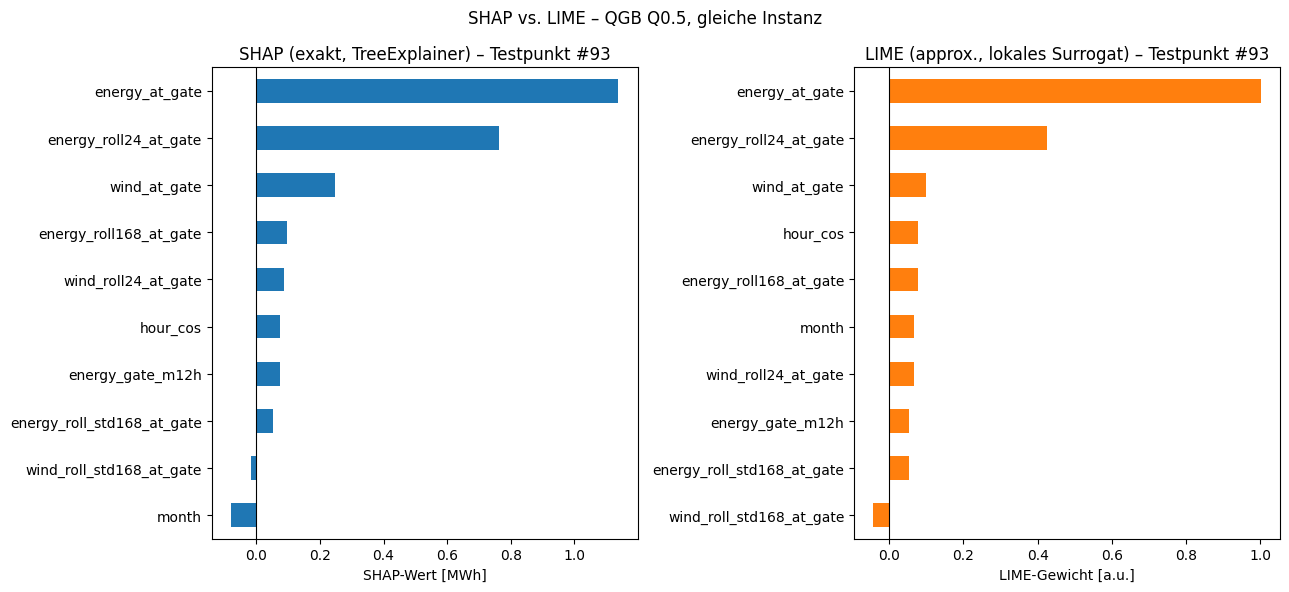

Spearman ρ |SHAP| vs |LIME| (alle Features): 0.786


In [19]:
try:
    import lime
    import lime.lime_tabular

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train, feature_names=FEATURES, mode="regression", random_state=42,
    )
    lime_exp = lime_explainer.explain_instance(
        X_test[:100][SHARED_IDX],
        qgb_models[TAU_QGB].predict,
        num_features=len(FEATURES),
        num_samples=1000,
    )
    lime_weights = np.zeros(len(FEATURES))
    for feat_idx, weight in lime_exp.local_exp[1]:
        lime_weights[feat_idx] = weight
    lime_series   = pd.Series(lime_weights, index=FEATURES)
    shap_instance = pd.Series(shap_vals_qgb[SHARED_IDX], index=FEATURES)

    top_feats  = shap_instance.abs().sort_values(ascending=False).head(10).index
    comparison = pd.DataFrame({"SHAP": shap_instance[top_feats],
                               "LIME": lime_series[top_feats]})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    comparison["SHAP"].sort_values().plot(kind="barh", ax=ax1, color="#1f77b4")
    ax1.axvline(0, color="black", linewidth=0.8)
    ax1.set_title(f"SHAP (exakt, TreeExplainer) – Testpunkt #{SHARED_IDX}")
    ax1.set_xlabel("SHAP-Wert [MWh]")
    comparison["LIME"].sort_values().plot(kind="barh", ax=ax2, color="#ff7f0e")
    ax2.axvline(0, color="black", linewidth=0.8)
    ax2.set_title(f"LIME (approx., lokales Surrogat) – Testpunkt #{SHARED_IDX}")
    ax2.set_xlabel("LIME-Gewicht [a.u.]")
    plt.suptitle("SHAP vs. LIME – QGB Q0.5, gleiche Instanz", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "shap_vs_lime.png", dpi=150, bbox_inches="tight")
    plt.show()

    rho_lime, _ = spearmanr(shap_instance.abs(), lime_series.abs())
    print(f"Spearman ρ |SHAP| vs |LIME| (alle Features): {rho_lime:.3f}")

except ImportError:
    print("lime nicht installiert – Installation: pip install lime")
    print("Abschnitt 12 wird übersprungen.")

## 13. Prognosequalität vs. Ökonomische Güte

Zeigt ob statistische Qualität (RMSE) mit wirtschaftlicher Güte (Pinball Loss Q0.5) korreliert.
Pinball Loss bei τ=0.5 = mittlerer absoluter Fehler gewichtet nach Über-/Unterschätzung —
direkter Proxy für den Newsvendor-Verlust.

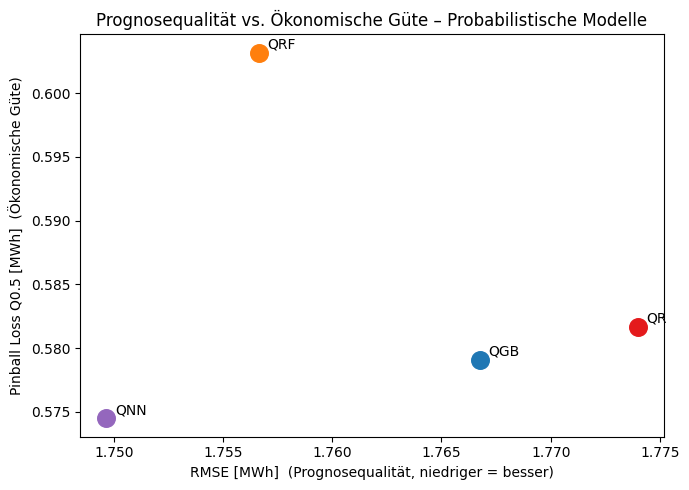


Korrelation RMSE ↔ Pinball Loss Q0.5:
  Spearman ρ = 0.400  (p = 0.6000)


In [20]:
pt_m = pd.read_csv(TABLES_DIR / "point_forecast_metrics_day_ahead.csv").set_index("model")
pb_m = pd.read_csv(TABLES_DIR / "probabilistic_median_metrics_day_ahead.csv").set_index("model")
pinball_df = pd.read_csv(TABLES_DIR / "pinball_metrics_day_ahead.csv")
pinball_q50 = pinball_df[pinball_df["quantile"] == 0.5].set_index("model")["pinball_loss"]

prob_models = {
    "QR":  ("Quantile_Regression_q50",         "Quantile_Regression"),
    "QRF": ("QRF_q50",                          "QRF"),
    "QGB": ("Quantile_Gradient_Boosting_q50",   "Quantile_Gradient_Boosting"),
    "QNN": ("Quantile_Neural_Network_q50",       "Quantile_Neural_Network"),
}
colors_prob = {"QR": "#e41a1c", "QRF": "#ff7f0e", "QGB": "#1f77b4", "QNN": "#9467bd"}

fig, ax = plt.subplots(figsize=(7, 5))
for label, (rmse_key, pb_key) in prob_models.items():
    rmse = pb_m.loc[rmse_key, "RMSE"]
    pl   = pinball_q50[pb_key]
    ax.scatter(rmse, pl, color=colors_prob[label], s=160, zorder=5)
    ax.annotate(label, (rmse, pl), textcoords="offset points", xytext=(6, 3), fontsize=10)

ax.set_xlabel("RMSE [MWh]  (Prognosequalität, niedriger = besser)")
ax.set_ylabel("Pinball Loss Q0.5 [MWh]  (Ökonomische Güte)")
ax.set_title("Prognosequalität vs. Ökonomische Güte – Probabilistische Modelle")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "forecast_quality_vs_cost.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKorrelation RMSE ↔ Pinball Loss Q0.5:")
rmse_list  = [pb_m.loc[v[0], "RMSE"]     for v in prob_models.values()]
pl_list    = [pinball_q50[v[1]]           for v in prob_models.values()]
from scipy.stats import spearmanr as _sp
rho, pval = _sp(rmse_list, pl_list)
print(f"  Spearman ρ = {rho:.3f}  (p = {pval:.4f})")

## 14. Explainability–Robustness Mapping

Jedes Modell wird auf zwei Achsen positioniert:
- **Erklärbarkeit**: wie direkt und axiomatisch begründet sind die Erklärungen?
  Koeffizienten (exakt) > TreeExplainer (exakt, SHAP) > KernelExplainer (approx.)
- **Robustheit**: normierte Prognosequalität — `1 − (RMSE − min) / (max − min)`

Forschungsfrage: Sind interpretierbare Modelle trotz geringerer Modellflexibilität
wirtschaftlich konkurrenzfähig gegenüber Black-Box-Modellen?

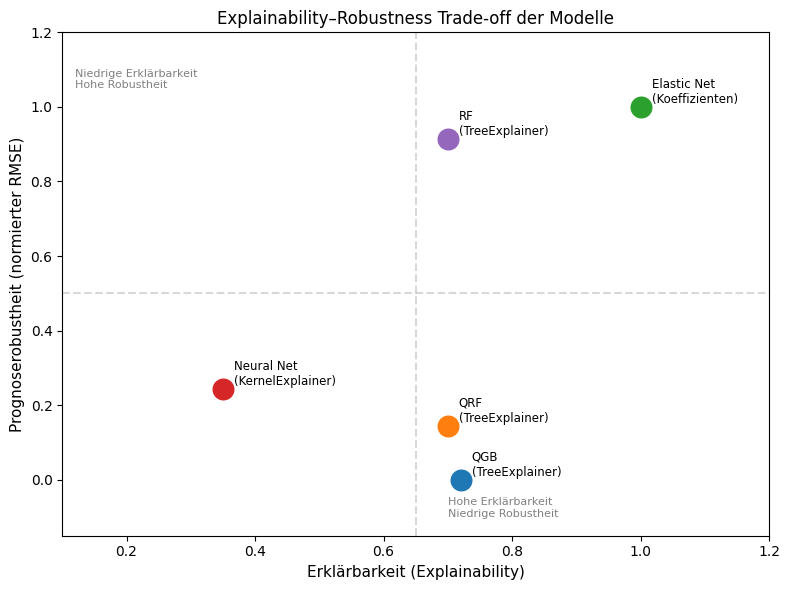

In [21]:
try:
    pt_m  = pd.read_csv(TABLES_DIR / "point_forecast_metrics_day_ahead.csv").set_index("model")
    pb_m  = pd.read_csv(TABLES_DIR / "probabilistic_median_metrics_day_ahead.csv").set_index("model")
    rmse_lookup = {**pt_m["RMSE"].to_dict(), **pb_m["RMSE"].to_dict()}
except FileNotFoundError:
    rmse_lookup = {}

model_meta = {
    "Elastic Net\n(Koeffizienten)": {"rmse_key": "Elastic_Net",                     "expl": 1.00, "color": "#2ca02c"},
    "QGB\n(TreeExplainer)":         {"rmse_key": "Quantile_Gradient_Boosting_q50",   "expl": 0.72, "color": "#1f77b4"},
    "QRF\n(TreeExplainer)":         {"rmse_key": "QRF_q50",                          "expl": 0.70, "color": "#ff7f0e"},
    "RF\n(TreeExplainer)":          {"rmse_key": "Random_Forest",                    "expl": 0.70, "color": "#9467bd"},
    "Neural Net\n(KernelExplainer)":{"rmse_key": "Quantile_Neural_Network_q50",      "expl": 0.35, "color": "#d62728"},
}
fallback_rmse = {"Elastic_Net": 1.719, "Quantile_Gradient_Boosting_q50": 1.789,
                 "QRF_q50": 1.831, "Random_Forest": 1.793, "Quantile_Neural_Network_q50": 1.771}

rmse_vals = np.array([rmse_lookup.get(m["rmse_key"], fallback_rmse[m["rmse_key"]])
                      for m in model_meta.values()])
robustness = 1 - (rmse_vals - rmse_vals.min()) / (rmse_vals.max() - rmse_vals.min() + 1e-9)

fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, meta) in enumerate(model_meta.items()):
    ax.scatter(meta["expl"], robustness[i], color=meta["color"], s=220, zorder=5)
    ax.annotate(name, (meta["expl"], robustness[i]),
                textcoords="offset points", xytext=(8, 3), fontsize=8.5)
ax.set_xlabel("Erklärbarkeit (Explainability)", fontsize=11)
ax.set_ylabel("Prognoserobustheit (normierter RMSE)", fontsize=11)
ax.set_title("Explainability–Robustness Trade-off der Modelle")
ax.set_xlim(0.1, 1.2)
ax.set_ylim(-0.15, 1.2)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.3)
ax.axvline(0.65, color="gray", linestyle="--", alpha=0.3)
ax.text(0.12, 1.05, "Niedrige Erklärbarkeit\nHohe Robustheit", fontsize=8, color="gray")
ax.text(0.70, -0.10, "Hohe Erklärbarkeit\nNiedrige Robustheit", fontsize=8, color="gray")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "explainability_robustness_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Fehleranalyse - Wann scheitern Gebote?

Analysiert unter welchen Feature-Konstellationen der Bietfehler am groessten ist.

**Definition Bietfehler:** `error_t = b_t - y_t`
- `error_t > 0`: Uebergebot (mehr geboten als produziert -> Ueberdeckung)
- `error_t < 0`: Untergebot (weniger geboten als produziert -> Unterdeckung)

Untersucht werden: saisonale Muster, Windvolatilitaet und aktuelle Produktionshoehe.

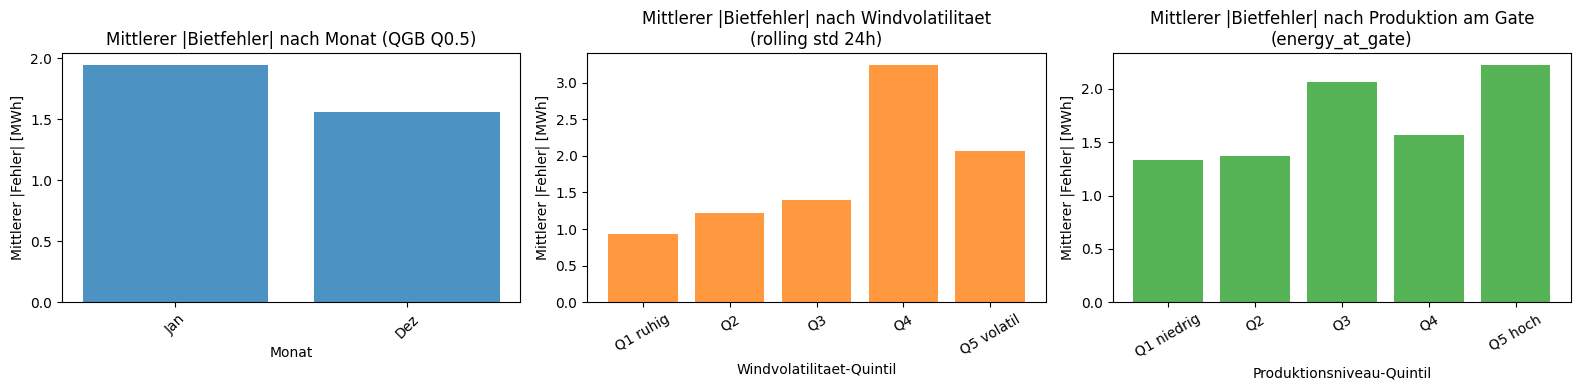

Korrelation |Fehler| - Windvolatilitaet: 0.236
Korrelation |Fehler| - Produktion am Gate: 0.214


In [22]:
y      = df_model[TARGET].to_numpy()
y_train = y[:split_idx]
y_test  = y[split_idx:]

# Bietfehler berechnen (QGB Q0.5 als repr. Gebotsmodell)
bids_qgb = qgb_models[TAU_QGB].predict(X_test[:500])
y_actual = y_test[:500]
errors   = bids_qgb - y_actual
abs_err  = np.abs(errors)

test_ts_err = df_model['timestamp'].iloc[split_idx: split_idx + 500].reset_index(drop=True)
df_err = pd.DataFrame({
    'timestamp':         test_ts_err,
    'error':             errors,
    'abs_error':         abs_err,
    'month':             test_ts_err.dt.month,
    'hour':              test_ts_err.dt.hour,
    'energy_at_gate':    X_test[:500, FEATURES.index('energy_at_gate')],
    'wind_roll_std24':   X_test[:500, FEATURES.index('wind_roll_std24_at_gate')],
})

month_labels = {1:'Jan',2:'Feb',3:'Mrz',4:'Apr',5:'Mai',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Okt',11:'Nov',12:'Dez'}
monthly_err = df_err.groupby('month')['abs_error'].mean()
monthly_err.index = [month_labels[m] for m in monthly_err.index]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Fehler nach Monat
axes[0].bar(monthly_err.index, monthly_err.values, color='#1f77b4', alpha=0.8)
axes[0].set_title('Mittlerer |Bietfehler| nach Monat (QGB Q0.5)')
axes[0].set_xlabel('Monat'); axes[0].set_ylabel('Mittlerer |Fehler| [MWh]')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Fehler vs. Windvolatilitaet
df_err['vol_quintile'] = pd.qcut(df_err['wind_roll_std24'], q=5,
                                  labels=['Q1 ruhig','Q2','Q3','Q4','Q5 volatil'])
vol_err = df_err.groupby('vol_quintile', observed=True)['abs_error'].mean()
axes[1].bar(range(len(vol_err)), vol_err.values, color='#ff7f0e', alpha=0.8)
axes[1].set_xticks(range(len(vol_err))); axes[1].set_xticklabels(vol_err.index, rotation=30)
axes[1].set_title('Mittlerer |Bietfehler| nach Windvolatilitaet\n(rolling std 24h)')
axes[1].set_xlabel('Windvolatilitaet-Quintil'); axes[1].set_ylabel('Mittlerer |Fehler| [MWh]')

# Plot 3: Fehler vs. Produktionsniveau
df_err['gate_quintile'] = pd.qcut(df_err['energy_at_gate'], q=5,
                                   labels=['Q1 niedrig','Q2','Q3','Q4','Q5 hoch'])
gate_err = df_err.groupby('gate_quintile', observed=True)['abs_error'].mean()
axes[2].bar(range(len(gate_err)), gate_err.values, color='#2ca02c', alpha=0.8)
axes[2].set_xticks(range(len(gate_err))); axes[2].set_xticklabels(gate_err.index, rotation=30)
axes[2].set_title('Mittlerer |Bietfehler| nach Produktion am Gate\n(energy_at_gate)')
axes[2].set_xlabel('Produktionsniveau-Quintil'); axes[2].set_ylabel('Mittlerer |Fehler| [MWh]')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'bid_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Korrelation |Fehler| - Windvolatilitaet:',
      df_err[['abs_error','wind_roll_std24']].corr().iloc[0,1].round(3))
print('Korrelation |Fehler| - Produktion am Gate:',
      df_err[['abs_error','energy_at_gate']].corr().iloc[0,1].round(3))


## 11. Zusammenfassung

In [23]:
print("=" * 65)
print("XAI ANALYSIS – ZUSAMMENFASSUNG")
print("=" * 65)

# Top-3 jedes Modells
summary_data = {
    "QGB (tau*=Q0.5)":    pd.Series(np.abs(shap_vals_qgb).mean(axis=0), index=FEATURES),
    "QRF (E[y|X]-Proxy)": pd.Series(np.abs(shap_vals_qrf).mean(axis=0), index=FEATURES),
    "RF (Point)":          pd.Series(np.abs(shap_vals_rf).mean(axis=0),  index=FEATURES),
    "Neural Net":          pd.Series(np.abs(shap_arr_nn).mean(axis=0),   index=FEATURES),
}
print("\nTop-5 Features pro Modell:")
top5 = pd.DataFrame({k: v.sort_values(ascending=False).head(5).index.tolist()
                     for k, v in summary_data.items()},
                    index=[f"Rang {i+1}" for i in range(5)])
display(top5)

# Verbindung zu NB04: Lade Bidding-Ergebnisse
try:
    bidding = pd.read_csv(TABLES_DIR / "bidding_results_day_ahead.csv")
    best_bid = bidding[bidding["model"] != "Oracle (perfekt)"].iloc[0]
    print(f"\nBestes Bidding-Modell (NB04): {best_bid['model']}")
    print(f"  Mean NV Loss: {best_bid['mean_nv_loss']:.4f} EUR/h")
    print(f"  -> Dieses Modell wird in Abschnitt 5 (SHAP-QGB) erklaert.")
except FileNotFoundError:
    print("\n(bidding_results_day_ahead.csv nicht gefunden - erst NB04 ausfuehren)")

print("\nGespeicherte Abbildungen:")
for f in sorted(FIGURES_DIR.glob("shap_*.png")):
    print(f"  {f.name}")

XAI ANALYSIS – ZUSAMMENFASSUNG

Top-5 Features pro Modell:


,QGB (tau*=Q0.5),QRF (E[y|X]-Proxy),RF (Point),Neural Net
Rang 1,energy_at_gate,energy_at_gate,energy_at_gate,month
Rang 2,energy_roll24_at_gate,energy_roll24_at_gate,energy_roll24_at_gate,wind_at_gate
Rang 3,energy_roll168_at_gate,month,month,energy_gate_m168h
Rang 4,hour_cos,energy_roll168_at_gate,wind_at_gate,wind_roll_std168_at_gate
Rang 5,month,hour_cos,hour_cos,wind_gate_m168h



Bestes Bidding-Modell (NB04): Quantile_Neural_Network (q50)
  Mean NV Loss: 34.5009 EUR/h
  -> Dieses Modell wird in Abschnitt 5 (SHAP-QGB) erklaert.

Gespeicherte Abbildungen:
  shap_en_coefs.png
  shap_feature_importance_comparison_tree.png
  shap_nn_bar.png
  shap_nn_summary.png
  shap_nn_waterfall.png
  shap_qgb_bar.png
  shap_qgb_monthly.png
  shap_qgb_tau50_summary.png
  shap_qgb_waterfall.png
  shap_qrf_bar.png
  shap_qrf_summary.png
  shap_qrf_waterfall.png
  shap_rf_bar.png
  shap_rf_summary.png
  shap_rf_waterfall.png
  shap_vs_lime.png
